# Bloco 3 — Modelo de Previsão

Treino, validação e exportação do modelo preditivo de cobertura de Housekeeping.

- Prepara o dataset preditivo a partir dos CSVs históricos
- Compara três modelos com split 80/20 temporal
- Valida com `TimeSeriesSplit` (5 folds)
- Exporta quatro artefactos `.pkl` para o Bloco 4

> **Semana-alvo:** a semana-alvo pode ser redefinida na secção de configuração.

## 1. Configuração

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LinearRegression
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib

ROOT_DIR    = Path.cwd().parent
DATA_DIR    = ROOT_DIR / "data" / "synthetic"
OUTPUTS_DIR = ROOT_DIR / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

# Semana-alvo para o Bloco 4
SEMANA_PREV_INICIO = "2025-01-01"
SEMANA_PREV_FIM    = "2025-01-07"

print(f"ROOT_DIR    : {ROOT_DIR}")
print(f"OUTPUTS_DIR : {OUTPUTS_DIR}")
print(f"Semana-alvo : {SEMANA_PREV_INICIO} → {SEMANA_PREV_FIM}")

ROOT_DIR    : c:\Projetos\Projeto Final\hotel_scheduling
OUTPUTS_DIR : c:\Projetos\Projeto Final\hotel_scheduling\outputs
Semana-alvo : 2025-01-01 → 2025-01-07


## 2. Dataset de treino

Construído por agregação da actividade hoteleira diária e merge com as necessidades de cobertura históricas.

In [2]:
# Carregar CSVs
colaboradores      = pd.read_csv(DATA_DIR / "colaboradores.csv")
cobertura          = pd.read_csv(DATA_DIR / "cobertura_necessidades.csv", parse_dates=["data"])
atividade          = pd.read_csv(DATA_DIR / "atividade_hotel.csv",        parse_dates=["data"])
atividade_tipologia = pd.read_csv(DATA_DIR / "atividade_tipologia.csv",  parse_dates=["data"])

# Filtrar apenas T1 e T2
cobertura = cobertura[cobertura["turno_id"].isin(["T1", "T2"])].copy()

# 1) Agregação diária por tipologia
atv_tip_agg = (
    atividade_tipologia
    .groupby("data", as_index=False)
    .agg(
        carga_total_min        = ("carga_limpeza_min",  "sum"),
        quartos_checkout_total = ("quartos_checkout",   "sum"),
        quartos_stayover_total = ("quartos_stayover",   "sum"),
    )
)

# 2) Enriquecer atividade
atividade_modelo = atividade.merge(atv_tip_agg, on="data", how="left")

# 3) Merge com cobertura
df_train = cobertura.merge(atividade_modelo, on="data", how="left")
if "dia_semana_x" in df_train.columns:
    df_train = df_train.rename(columns={"dia_semana_y": "dia_semana"}).drop(columns=["dia_semana_x"])

# 4) Seleccionar features
colunas_modelo = [
    "data", "turno_id", "funcao",
    "colaboradores_minimos", "colaboradores_ideais",
    "taxa_ocupacao", "quartos_ocupados", "n_checkins", "n_checkouts",
    "evento_especial", "tipo_dia", "epoca", "mes", "dia_semana",
    "quartos_a_limpar_estimados", "carga_total_min",
    "quartos_checkout_total", "quartos_stayover_total",
]
df_modelo = (
    df_train[colunas_modelo]
    .sort_values("data")
    .reset_index(drop=True)
)

print(f"Dataset: {df_modelo.shape[0]} registos | {df_modelo['data'].min().date()} → {df_modelo['data'].max().date()}")
print(f"Funções: {sorted(df_modelo['funcao'].unique())}")

Dataset: 2190 registos | 2025-01-01 → 2025-12-31
Funções: ['Auxiliar de limpeza', 'Empregada de andares', 'Supervisora']


## 3. Features e split temporal

Split 80/20 temporal para comparação de modelos. One-hot encoding nas variáveis categóricas — colunas guardadas em `gb_features.pkl` para garantir alinhamento no Bloco 4.

In [3]:
features = [
    "turno_id", "funcao", "taxa_ocupacao", "quartos_ocupados",
    "n_checkins", "n_checkouts", "evento_especial", "tipo_dia",
    "epoca", "mes", "dia_semana", "quartos_a_limpar_estimados",
    "carga_total_min", "quartos_checkout_total", "quartos_stayover_total",
]
cat_cols = ["turno_id", "funcao", "tipo_dia", "epoca", "dia_semana"]

# Target principal (v1)
y = df_modelo["colaboradores_minimos"].copy()

# Encoding one-hot
X_final = pd.get_dummies(df_modelo[features], columns=cat_cols, drop_first=False)

# Split temporal 80/20 (calculado sempre sobre X_final)
split_idx = int(len(X_final) * 0.8)
X_train, X_test = X_final.iloc[:split_idx].copy(), X_final.iloc[split_idx:].copy()
y_train, y_test = y.iloc[:split_idx].copy(),       y.iloc[split_idx:].copy()

assert len(X_test) == len(y_test)

print(f"Features    : {X_final.shape[1]} colunas após encoding")
print(f"Treino      : {X_train.shape[0]} registos | {df_modelo.iloc[:split_idx]['data'].min().date()} → {df_modelo.iloc[:split_idx]['data'].max().date()}")
print(f"Teste       : {X_test.shape[0]}  registos | {df_modelo.iloc[split_idx:]['data'].min().date()} → {df_modelo.iloc[split_idx:]['data'].max().date()}")

Features    : 29 colunas após encoding
Treino      : 1752 registos | 2025-01-01 → 2025-10-19
Teste       : 438  registos | 2025-10-20 → 2025-12-31


## 4. Comparação de modelos

Três modelos avaliados no mesmo split temporal. Arredondamento com `np.maximum(1, np.round(...)).astype(int)` em todos — N_min é um inteiro positivo.

In [4]:
gb_params = dict(n_estimators=200, learning_rate=0.05, max_depth=3,
                 min_samples_split=10, min_samples_leaf=5, random_state=42)

# Regressão Linear
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = np.maximum(1, np.round(lin_model.predict(X_test))).astype(int)
mae_lin  = mean_absolute_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin   = r2_score(y_test, y_pred_lin)

# Random Forest
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10,
    min_samples_split=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = np.maximum(1, np.round(rf_model.predict(X_test))).astype(int)
mae_rf    = mean_absolute_error(y_test, y_pred_rf)
rmse_rf   = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf     = r2_score(y_test, y_pred_rf)

# Gradient Boosting
gb_model = GradientBoostingRegressor(**gb_params)
gb_model.fit(X_train, y_train)
y_pred_gb = np.maximum(1, np.round(gb_model.predict(X_test))).astype(int)
mae_gb    = mean_absolute_error(y_test, y_pred_gb)
rmse_gb   = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb     = r2_score(y_test, y_pred_gb)

pd.DataFrame({
    "Modelo" : ["Regressão Linear", "Random Forest", "Gradient Boosting ✓"],
    "MAE"    : [round(mae_lin,3),  round(mae_rf,3),  round(mae_gb,3)],
    "RMSE"   : [round(rmse_lin,3), round(rmse_rf,3), round(rmse_gb,3)],
    "R²"     : [round(r2_lin,3),   round(r2_rf,3),   round(r2_gb,3)],
})

,Modelo,MAE,RMSE,R²
0,Regressão Linear,0.258,0.508,0.797
1,Random Forest,0.226,0.475,0.822
2,Gradient Boosting ✓,0.201,0.448,0.842


## 5. Importância das features

As variáveis associadas à função, ao turno e ao contexto temporal surgem entre os preditores mais relevantes.

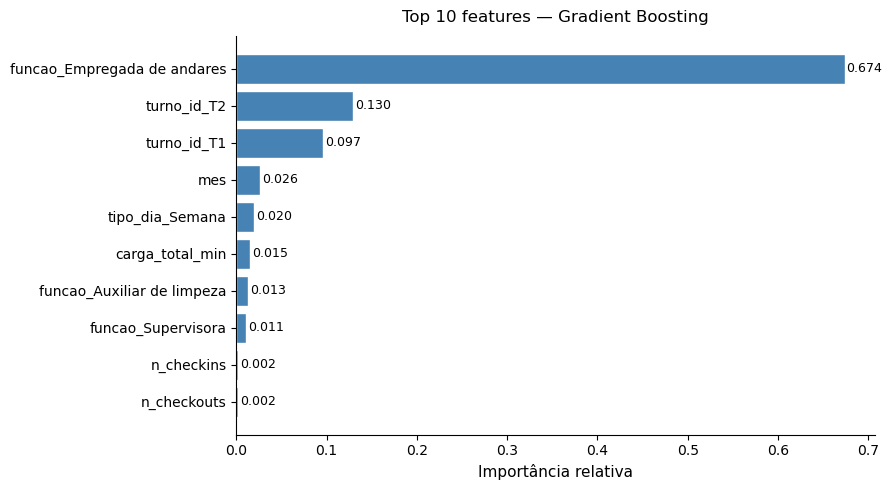

In [5]:
importancias = pd.Series(
    gb_model.feature_importances_, index=X_final.columns
).sort_values(ascending=False)

top10 = importancias.nlargest(10).sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top10.index, top10.values, color="steelblue", edgecolor="white")
for bar, val in zip(bars, top10.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)
ax.set_xlabel("Importância relativa", fontsize=11)
ax.set_title("Top 10 features — Gradient Boosting", fontsize=12, pad=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Validação temporal — TimeSeriesSplit (5 folds)

Avaliação em 5 horizontes temporais distintos, incluindo épocas não vistas em cada fold.

In [6]:
tscv = TimeSeriesSplit(n_splits=5)
rows = []

for target_name, target_label in [
    ("colaboradores_minimos", "N_min  → H1"),
    ("colaboradores_ideais",  "N_ideal → S4"),
]:
    y_tss = df_modelo[target_name].copy()
    maes, rmses, r2s = [], [], []
    for tr_idx, te_idx in tscv.split(X_final):
        gb_f = GradientBoostingRegressor(**gb_params)
        gb_f.fit(X_final.iloc[tr_idx], y_tss.iloc[tr_idx])
        y_p = np.maximum(1, np.round(gb_f.predict(X_final.iloc[te_idx]))).astype(int)
        maes.append(mean_absolute_error(y_tss.iloc[te_idx], y_p))
        rmses.append(np.sqrt(mean_squared_error(y_tss.iloc[te_idx], y_p)))
        r2s.append(r2_score(y_tss.iloc[te_idx], y_p))
    rows.append({
        "Target"   : target_label,
        "MAE médio": round(np.mean(maes), 3),
        "MAE std"  : round(np.std(maes),  3),
        "RMSE médio": round(np.mean(rmses), 3),
        "R² médio" : round(np.mean(r2s),  3),
    })

pd.DataFrame(rows)

,Target,MAE médio,MAE std,RMSE médio,R² médio
0,N_min → H1,0.253,0.105,0.516,0.804
1,N_ideal → S4,0.299,0.110,0.564,0.835


## 7. Treino final

Modelos treinados no dataset completo (sem reserva de teste) — prática standard após validação.

In [7]:
# Modelo final v1: colaboradores_minimos → N_min
gb_model = GradientBoostingRegressor(**gb_params)
gb_model.fit(X_final, df_modelo["colaboradores_minimos"])
print(f"gb_model    : {type(gb_model).__name__} | target=colaboradores_minimos | {len(X_final)} registos")

# Modelo final v2: colaboradores_ideais → N_ideal
gb_model_v2 = GradientBoostingRegressor(**gb_params)
gb_model_v2.fit(X_final, df_modelo["colaboradores_ideais"])
print(f"gb_model_v2 : {type(gb_model_v2).__name__} | target=colaboradores_ideais | {len(X_final)} registos")

gb_model    : GradientBoostingRegressor | target=colaboradores_minimos | 2190 registos
gb_model_v2 : GradientBoostingRegressor | target=colaboradores_ideais | 2190 registos


## 8. Exportação dos artefactos

In [8]:
joblib.dump(gb_model,               OUTPUTS_DIR / "gb_model.pkl")
joblib.dump(gb_model_v2,            OUTPUTS_DIR / "gb_model_v2.pkl")
joblib.dump(list(X_final.columns),  OUTPUTS_DIR / "gb_features.pkl")
joblib.dump(
    {"semana_inicio": SEMANA_PREV_INICIO, "semana_fim": SEMANA_PREV_FIM},
    OUTPUTS_DIR / "gb_config.pkl",
)

print("Artefactos exportados:")
print(f"  gb_model.pkl      → {type(gb_model).__name__}  (N_min)")
print(f"  gb_model_v2.pkl   → {type(gb_model_v2).__name__}  (N_ideal)")
print(f"  gb_features.pkl   → {len(X_final.columns)} features")
print(f"  gb_config.pkl     → {SEMANA_PREV_INICIO} a {SEMANA_PREV_FIM}")
print(f"  Destino: {OUTPUTS_DIR}")

Artefactos exportados:
  gb_model.pkl      → GradientBoostingRegressor  (N_min)
  gb_model_v2.pkl   → GradientBoostingRegressor  (N_ideal)
  gb_features.pkl   → 29 features
  gb_config.pkl     → 2025-01-01 a 2025-01-07
  Destino: c:\Projetos\Projeto Final\hotel_scheduling\outputs


## 9. Previsão para a semana-alvo

Confirmação do que o Bloco 4 irá receber como input — comparação entre N_min real e previsto.

In [9]:
datas_prev = pd.date_range(SEMANA_PREV_INICIO, SEMANA_PREV_FIM)
df_alvo    = df_modelo[df_modelo["data"].isin(datas_prev)].copy()

if df_alvo.empty:
    print("⚠️  Semana-alvo fora do dataset — sem dados históricos para comparação.")
else:
    X_alvo = pd.get_dummies(df_alvo[features], columns=cat_cols, drop_first=False)
    X_alvo = X_alvo.reindex(columns=X_final.columns, fill_value=0)

    df_alvo["N_min_previsto"]   = np.maximum(1, np.round(gb_model.predict(X_alvo))).astype(int)
    df_alvo["N_ideal_previsto"] = np.maximum(1, np.ceil(gb_model_v2.predict(X_alvo))).astype(int)
    df_alvo["N_min_real"]       = df_alvo["colaboradores_minimos"]
    df_alvo["diff"]             = df_alvo["N_min_previsto"] - df_alvo["N_min_real"]

    iguais = (df_alvo["diff"] == 0).sum()
    print(f"Semana  : {SEMANA_PREV_INICIO} → {SEMANA_PREV_FIM}")
    print(f"Exactas : {iguais}/{len(df_alvo)} ({iguais/len(df_alvo)*100:.0f}%)")
    print(f"N_min total previsto : {df_alvo['N_min_previsto'].sum()} turnos")

    display(
        df_alvo[["data", "turno_id", "funcao", "N_min_real", "N_min_previsto", "diff"]]
        .sort_values(["data", "turno_id", "funcao"])
        .reset_index(drop=True)
    )

Semana  : 2025-01-01 → 2025-01-07
Exactas : 38/42 (90%)
N_min total previsto : 77 turnos


,data,turno_id,funcao,N_min_real,N_min_previsto,diff
0,2025-01-01,T1,Auxiliar de limpeza,1,1,0
1,2025-01-01,T1,Empregada de andares,4,4,0
2,2025-01-01,T1,Supervisora,2,2,0
3,2025-01-01,T2,Auxiliar de limpeza,1,1,0
4,2025-01-01,T2,Empregada de andares,2,2,0
5,2025-01-01,T2,Supervisora,1,1,0
6,2025-01-02,T1,Auxiliar de limpeza,1,1,0
7,2025-01-02,T1,Empregada de andares,4,4,0
8,2025-01-02,T1,Supervisora,2,2,0
9,2025-01-02,T2,Auxiliar de limpeza,1,1,0
